<h1 style="text-align: center;">E-Commerce Customer Churn Prediction</h1>
<h3 style="text-align: center;">Donny & Hane </h3>

---

## **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja supaya proses selanjutnya konsisten dan reproducible.

### **0.1 Import Library**

In [1]:
# import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# preprocessing & pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# resampling (imbalanced-learn)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# model selection & evaluation
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV, learning_curve)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, fbeta_score, make_scorer)

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model persistence
import joblib

### **0.2 Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah machine learning sebelum menyentuh data.

### **1.1 Context**

Dalam industri e-commerce yang kompetitif, mempertahankan pelanggan jauh lebih murah dibanding mencari pelanggan baru. Menurut riset industri, biaya akuisisi pelanggan baru bisa 5–7× lebih mahal dibanding biaya retensi.

**Customer churn** (pelanggan berhenti menggunakan layanan) merupakan tantangan besar bagi platform e-commerce. Setiap pelanggan yang churn berarti hilangnya *recurring revenue* dan investasi akuisisi yang sia-sia.

Tim Marketing dan Customer Retention membutuhkan alat untuk **mengidentifikasi pelanggan berisiko churn lebih awal**, sehingga bisa melakukan intervensi proaktif (promosi, diskon, loyalty program) sebelum pelanggan benar-benar pergi.

### **1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur.

Dari total **3.941 pelanggan** dalam dataset, sekitar **17,1% (674 pelanggan) telah melakukan churn**. Pertanyaan bisnis:
- Pelanggan dengan karakteristik apa yang paling berisiko churn?
- Bisakah kita memprediksi churn **sebelum** terjadi, sehingga tim retention bisa melakukan intervensi tepat waktu?

### **1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini.

1. Membangun model klasifikasi yang mampu **memprediksi pelanggan yang akan churn** dengan kemampuan mendeteksi tinggi (minimize False Negatives).
2. Menghasilkan **daftar pelanggan berisiko** untuk prioritisasi intervensi.
3. Memberikan insight mengenai **faktor-faktor utama pendorong churn**.

### **1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis yang akan dipakai.

Masalah ini adalah **supervised binary classification** — label target `Churn` tersedia (0 = tidak churn, 1 = churn).

**Alur proyek:**
1. Data cleaning & EDA
2. Feature engineering dan preprocessing dalam Pipeline
3. Benchmarking beberapa algoritma klasifikasi
4. Hyperparameter tuning pada model terbaik
5. Evaluasi final, interpretasi, dan simulasi dampak bisnis

Model akan dipakai oleh **tim Customer Retention** secara periodik untuk men-*score* seluruh pelanggan aktif dan menyusun daftar prioritas intervensi.

### **1.5 Metric Evaluation**

> 🎯 *Tujuan:* Menjembatani metrik bisnis dengan metrik ML.

| Kondisi | Dampak Bisnis |
|---------|--------------|
| **False Negative (FN)** | Churn tidak terdeteksi → tidak ada intervensi → pelanggan hilang → kerugian **TINGGI** |
| **False Positive (FP)** | Tidak churn tapi diprediksi churn → intervensi tidak perlu → biaya kecil |

Karena **biaya FN >> biaya FP**, metrik yang diprioritaskan:

| Metrik | Peran |
|--------|-------|
| **Recall** | **Utama** — meminimalkan FN; seberapa banyak pelanggan churn berhasil terdeteksi |
| **F2-Score** | Variasi F-Score dengan bobot 2× pada Recall vs Precision |
| **ROC-AUC** | Kemampuan diskriminasi model secara keseluruhan |
| **Precision** | Sekunder — efisiensi intervensi |

### **1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka keberhasilan model.

Model dianggap **berhasil** apabila:
- **Recall ≥ 0.75** pada data testing
- **ROC-AUC ≥ 0.80**
- **F2-Score ≥ 0.70**

## **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum sebelum pembersihan atau analisis mendalam.

### **2.1 General Information**

In [3]:
# Load dataset
df = pd.read_csv("data_ecommerce_customer_churn.csv")

print(f"Dimensi dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print()
df.info()

Dimensi dataset: 3941 baris x 11 kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [4]:
df.head(10)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0
6,1.0,15.0,6,Mobile Phone,5,Divorced,3,0,2.0,149.51,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
9,17.0,7.0,3,Laptop & Accessory,1,Married,5,1,2.0,157.43,0


### **2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap bisnis.

| Feature | Tipe | Deskripsi | Relevansi Bisnis |
|---------|------|-----------|-----------------|
| `Tenure` | Numerik | Lama pelanggan menggunakan layanan (bulan) | Pelanggan baru cenderung lebih mudah churn |
| `WarehouseToHome` | Numerik | Jarak gudang ke rumah pelanggan (km) | Jarak jauh → pengiriman lama → kepuasan rendah |
| `NumberOfDeviceRegistered` | Numerik | Jumlah perangkat terdaftar di akun | Lebih banyak device → lebih engaged |
| `PreferedOrderCat` | Kategorikal | Kategori produk yang paling sering dipesan | Preferensi berkaitan dengan loyalitas |
| `SatisfactionScore` | Numerik | Skor kepuasan pelanggan (1–5) | Skor rendah → kemungkinan churn tinggi |
| `MaritalStatus` | Kategorikal | Status pernikahan pelanggan | Mempengaruhi pola belanja |
| `NumberOfAddress` | Numerik | Jumlah alamat pengiriman tersimpan | Banyak alamat → pelanggan lebih aktif |
| `Complain` | Biner (0/1) | Apakah pelanggan pernah komplain (1=Ya) | Komplain berkorelasi dengan risiko churn |
| `DaySinceLastOrder` | Numerik | Hari sejak terakhir memesan | Lama tidak order → berisiko churn |
| `CashbackAmount` | Numerik | Total cashback diterima pelanggan | Cashback tinggi → lebih engage dengan reward |
| `Churn` | Biner (0/1) | **TARGET** — apakah pelanggan churn (1=Ya) | Variabel yang ingin diprediksi |

### **2.3 Statistics Summary**

In [5]:
df.describe(include='all')

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941,3941.000000,3941,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
unique,NaN,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1458,NaN,2055,NaN,NaN,NaN,NaN,NaN
mean,10.081398,15.650583,3.679269,NaN,3.088302,NaN,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,NaN,1.381832,NaN,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,7.000000,195.250000,0.000000


In [6]:
# Distribusi target
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
print("Distribusi Target (Churn):")
print(pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)}))

Distribusi Target (Churn):
       Count  Percentage (%)
Churn                       
0       3267            82.9
1        674            17.1


## **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas sebelum dipakai lebih lanjut.

### **3.1 Missing Values**

In [7]:
missing     = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0]
print("Kolom dengan Missing Values:")
print(missing_df)

Kolom dengan Missing Values:
                   Missing Count  Missing %
Tenure                       194       4.92
WarehouseToHome              169       4.29
DaySinceLastOrder            213       5.40


In [8]:
# Strategi imputasi:
# - Tenure, WarehouseToHome, DaySinceLastOrder: imputasi MEDIAN (robust terhadap outlier)
# Imputasi dilakukan di dalam Pipeline (Section 5) untuk mencegah data leakage.
print("Strategi imputasi (dilakukan di dalam Pipeline):")
print("  - Tenure            : median")
print("  - WarehouseToHome   : median")
print("  - DaySinceLastOrder : median")

Strategi imputasi (dilakukan di dalam Pipeline):
  - Tenure            : median
  - WarehouseToHome   : median
  - DaySinceLastOrder : median


### **3.2 Duplicated Values**

In [9]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup} ({n_dup/len(df)*100:.2f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape setelah hapus duplikat: {df.shape}")

Jumlah baris duplikat: 671 (17.03%)
Shape setelah hapus duplikat: (3270, 11)


### **3.3 Data Consistency Check**

In [10]:
print("Unique values - PreferedOrderCat:")
print(df['PreferedOrderCat'].value_counts())
print()
print("Unique values - MaritalStatus:")
print(df['MaritalStatus'].value_counts())

Unique values - PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64

Unique values - MaritalStatus:
MaritalStatus
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64


In [11]:
# Inkonsistensi: 'Mobile' dan 'Mobile Phone' merujuk kategori yang sama
# Standarisasi: gabungkan menjadi 'Mobile Phone'
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})
print("Setelah standarisasi PreferedOrderCat:")
print(df['PreferedOrderCat'].value_counts())

Setelah standarisasi PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64


### **3.4 Identify Anomaly Values**

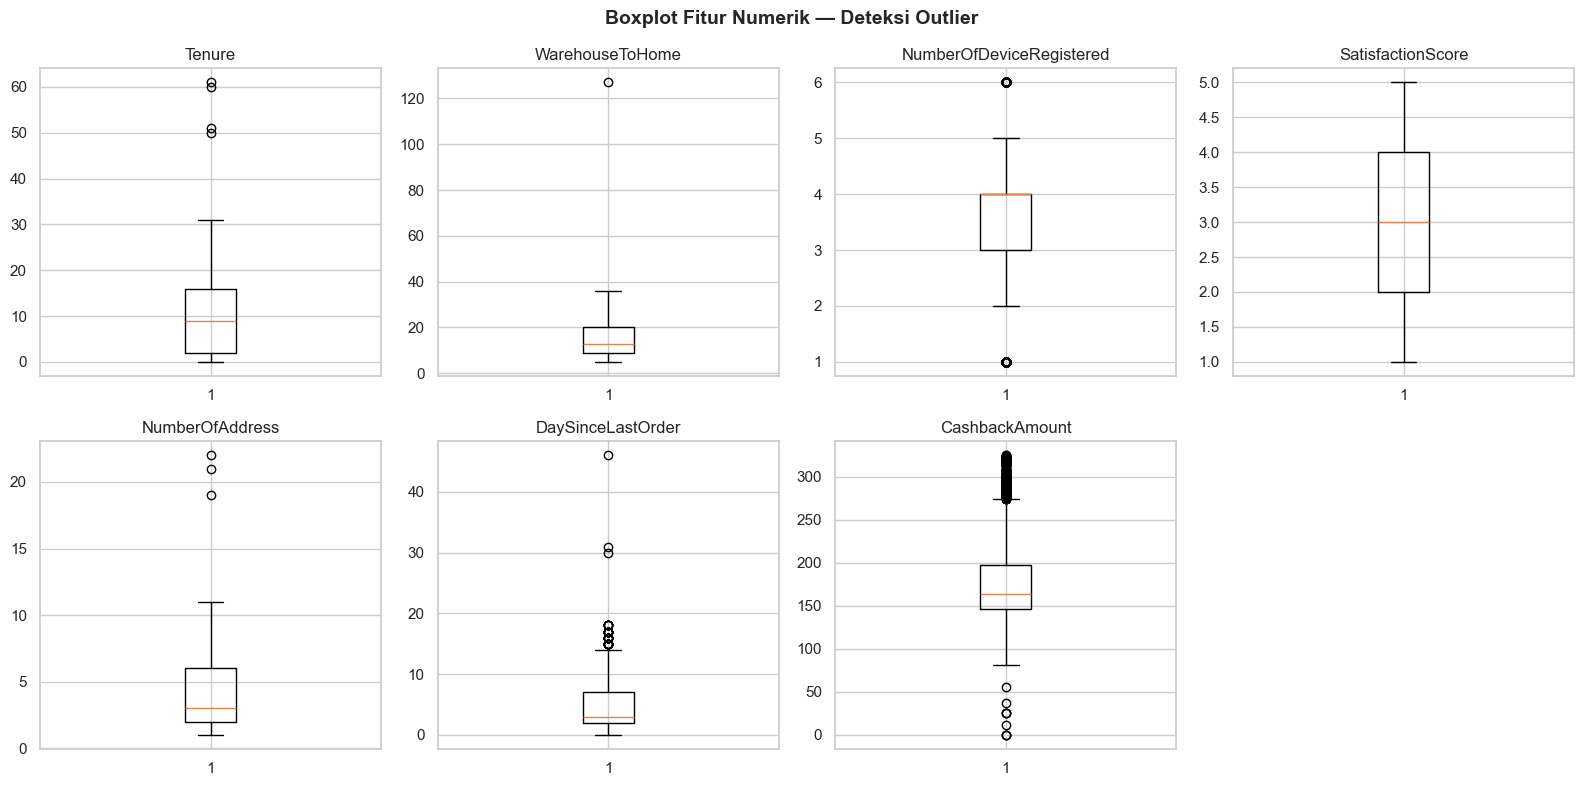

In [12]:
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Boxplot Fitur Numerik — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("Statistik WarehouseToHome:")
print(df['WarehouseToHome'].describe())
print(f"\nNilai > 100 km: {(df['WarehouseToHome'] > 100).sum()} baris")
print("Nilai ekstrem dipertahankan — mungkin merepresentasikan pelanggan daerah terpencil.")

Statistik WarehouseToHome:
count    3135.000000
mean       15.510367
std         8.568382
min         5.000000
25%         9.000000
50%        13.000000
75%        20.000000
max       127.000000
Name: WarehouseToHome, dtype: float64

Nilai > 100 km: 1 baris
Nilai ekstrem dipertahankan — mungkin merepresentasikan pelanggan daerah terpencil.


## **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data untuk membangun intuisi sebelum modeling.

### **4.1 Univariate Analysis**

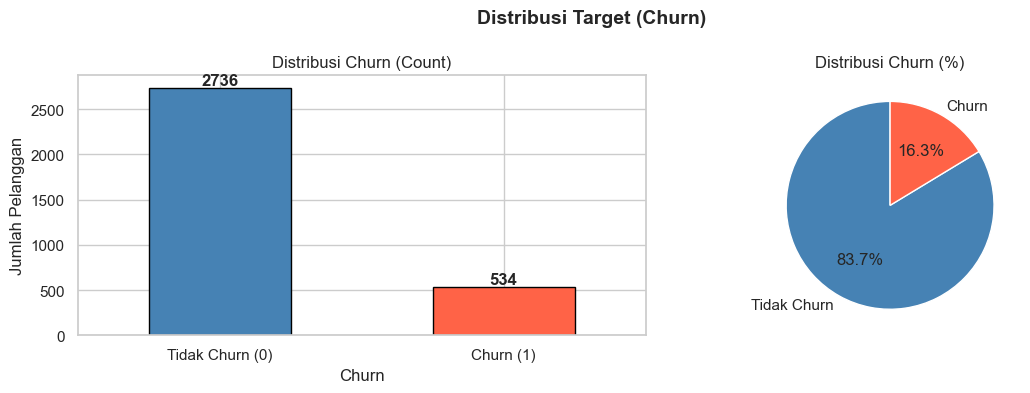

Dataset menunjukkan class imbalance (~17% churn). Perlu ditangani saat modeling.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribusi Churn (Count)')
axes[0].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Jumlah Pelanggan')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontweight='bold')

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['Tidak Churn', 'Churn'], colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Distribusi Churn (%)')
axes[1].set_ylabel('')

plt.suptitle('Distribusi Target (Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Dataset menunjukkan class imbalance (~17% churn). Perlu ditangani saat modeling.")

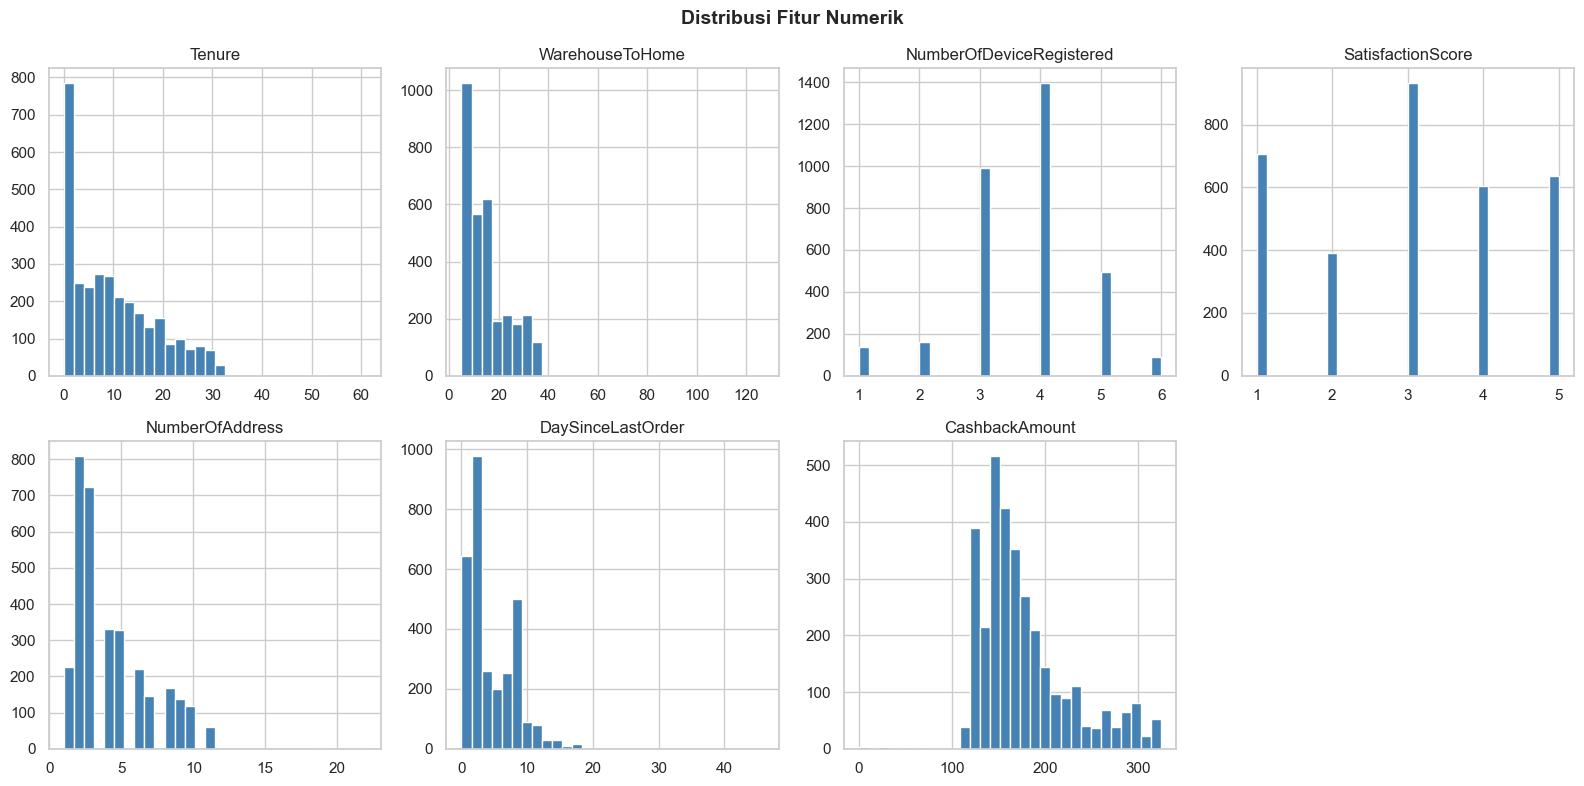

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

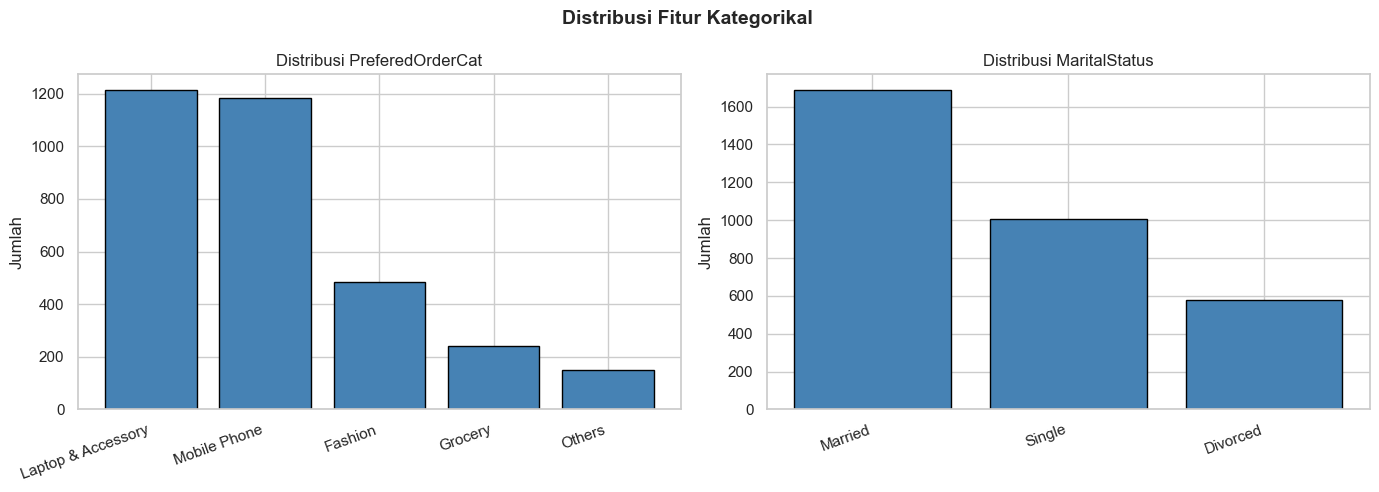

In [16]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_ylabel('Jumlah')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=20, ha='right')
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **4.2 Bivariate Analysis (terhadap Target)**

In [17]:
churn_group = df.groupby('Churn')[num_cols].mean().T
churn_group.columns = ['Tidak Churn', 'Churn']
print("Rata-rata Fitur Numerik per Kelas Churn:")
print(churn_group.round(2))

Rata-rata Fitur Numerik per Kelas Churn:
                          Tidak Churn   Churn
Tenure                          11.49    3.18
WarehouseToHome                 15.24   16.99
NumberOfDeviceRegistered         3.63    3.93
SatisfactionScore                2.96    3.33
NumberOfAddress                  4.17    4.50
DaySinceLastOrder                4.79    3.31
CashbackAmount                 180.72  160.51


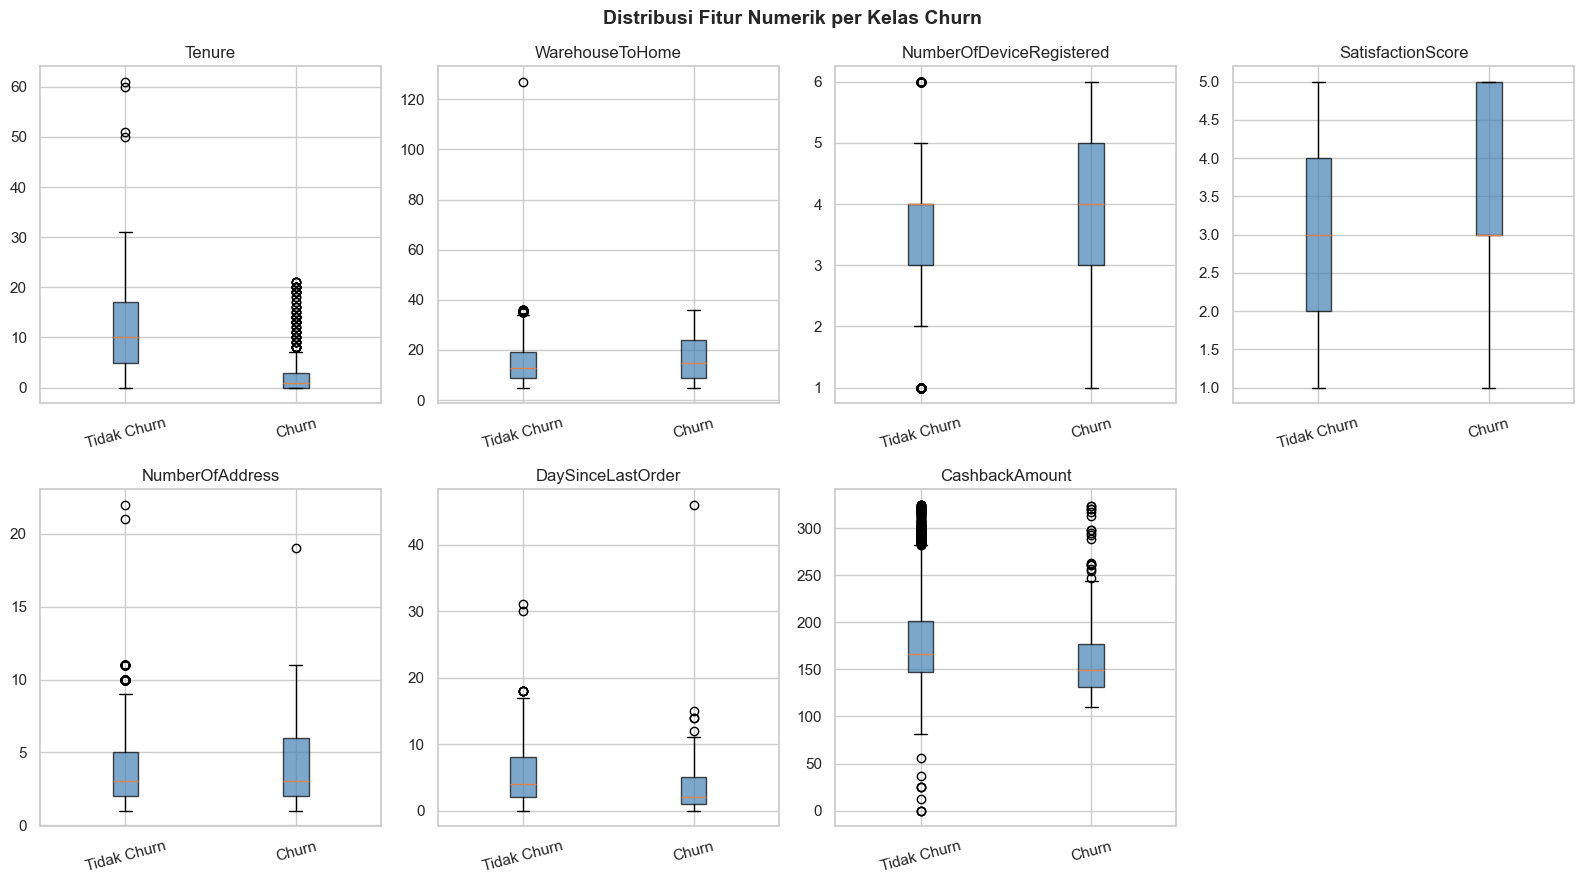

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    churn_0 = df[df['Churn']==0][col].dropna()
    churn_1 = df[df['Churn']==1][col].dropna()
    axes[i].boxplot([churn_0, churn_1], labels=['Tidak Churn', 'Churn'],
                    patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=15)
axes[-1].axis('off')
plt.suptitle('Distribusi Fitur Numerik per Kelas Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

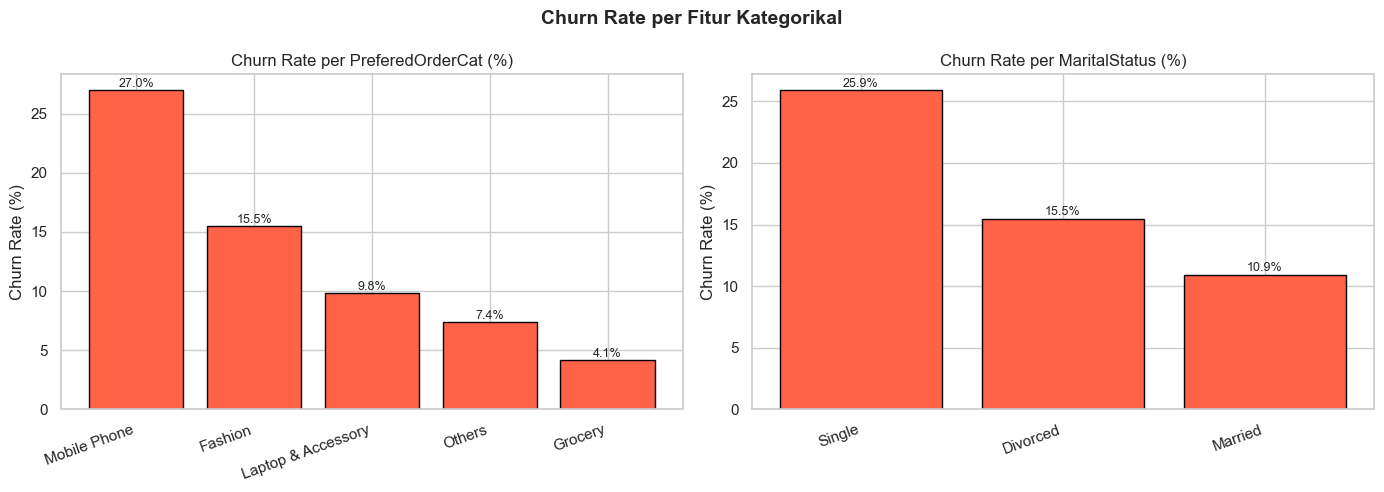

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(cat_cols):
    cr = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    axes[i].bar(cr.index, cr.values * 100, color='tomato', edgecolor='black')
    axes[i].set_title(f'Churn Rate per {col} (%)')
    axes[i].set_ylabel('Churn Rate (%)')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=20, ha='right')
    for j, v in enumerate(cr.values):
        axes[i].text(j, v*100+0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
plt.suptitle('Churn Rate per Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
complain_cr = df.groupby('Complain')['Churn'].mean() * 100
print("Churn Rate berdasarkan Keluhan (Complain):")
print(complain_cr.rename({0: 'Tidak Komplain', 1: 'Komplain'}).round(2))

Churn Rate berdasarkan Keluhan (Complain):
Complain
Tidak Komplain    10.26
Komplain          31.81
Name: Churn, dtype: float64


### **4.3 Correlation & Multicollinearity Check**

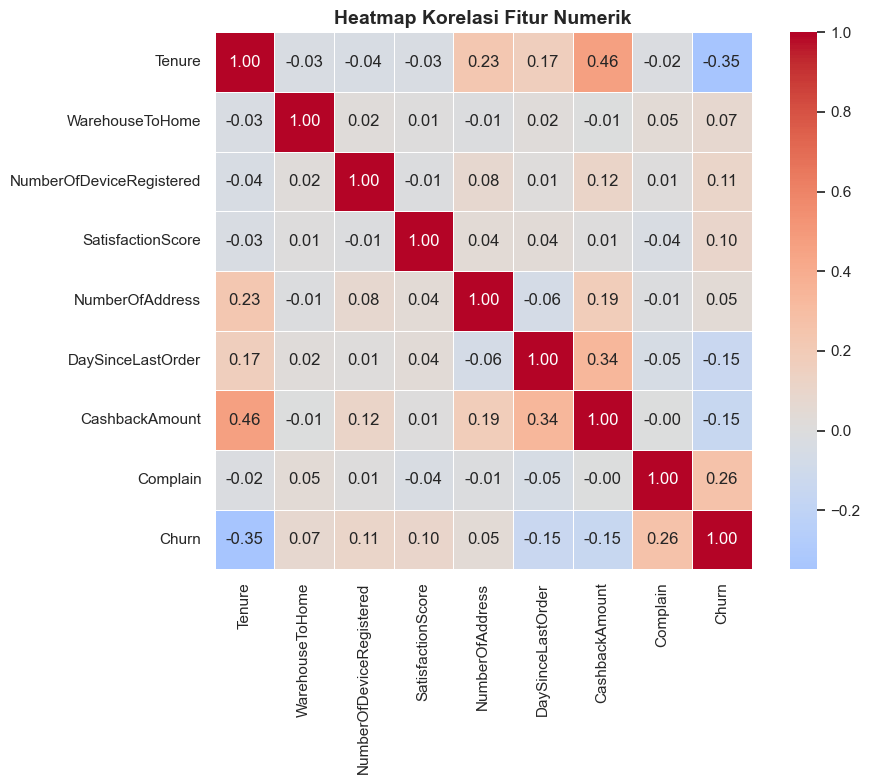

In [21]:
corr_cols = num_cols + ['Complain', 'Churn']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan.

### **5.1 Initialization**

In [22]:
def f2_score_fn(y_true, y_pred):
    """F2-Score: bobot 2x pada Recall vs Precision."""
    return fbeta_score(y_true, y_pred, beta=2)

f2_scorer = make_scorer(f2_score_fn)

FEATURES = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
            'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']
TARGET = 'Churn'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nDistribusi target:\n{y.value_counts()}")

Shape X: (3270, 10)
Shape y: (3270,)

Distribusi target:
Churn
0    2736
1     534
Name: count, dtype: int64


### **5.2 Constructing Training and Testing Data**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {X_train.shape[0]} baris")
print(f"Testing set  : {X_test.shape[0]} baris")
print(f"\nDistribusi target - Training:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribusi target - Testing:\n{y_test.value_counts(normalize=True).round(3)}")

Training set : 2616 baris
Testing set  : 654 baris

Distribusi target - Training:
Churn
0    0.837
1    0.163
Name: proportion, dtype: float64

Distribusi target - Testing:
Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


### **5.3 Handling Imbalanced Data**

In [24]:
print("Class imbalance terdeteksi (~83% kelas 0, ~17% kelas 1).")
print("Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.")
print("SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.")

Class imbalance terdeteksi (~83% kelas 0, ~17% kelas 1).
Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.
SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.


### **5.4 Data Transformation (Feature Engineering)**

In [25]:
# Definisi kolom berdasarkan tipe
num_missing    = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']
num_no_missing = ['NumberOfDeviceRegistered', 'SatisfactionScore',
                  'NumberOfAddress', 'Complain', 'CashbackAmount']
cat_features   = ['PreferedOrderCat', 'MaritalStatus']

# Transformer
num_missing_tr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])
num_no_missing_tr = Pipeline([('scaler', RobustScaler())])
cat_tr = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num_missing',    num_missing_tr,    num_missing),
    ('num_no_missing', num_no_missing_tr, num_no_missing),
    ('cat',            cat_tr,            cat_features)
])

print("Preprocessor berhasil didefinisikan.")
print(f"  Numerik (ada missing)   : {num_missing}")
print(f"  Numerik (tanpa missing) : {num_no_missing}")
print(f"  Kategorikal             : {cat_features}")

Preprocessor berhasil didefinisikan.
  Numerik (ada missing)   : ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']
  Numerik (tanpa missing) : ['NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'CashbackAmount']
  Kategorikal             : ['PreferedOrderCat', 'MaritalStatus']


### **5.5 Feature Selection**

In [26]:
print("Semua 10 fitur dipertahankan berdasarkan:")
print("  1. Domain knowledge (relevansi bisnis — lihat Section 2.2)")
print("  2. Tidak ada multikolinearitas tinggi (korelasi antar fitur < 0.8)")
print("  3. Semua fitur menunjukkan perbedaan distribusi antara churn/tidak churn")

Semua 10 fitur dipertahankan berdasarkan:
  1. Domain knowledge (relevansi bisnis — lihat Section 2.2)
  2. Tidak ada multikolinearitas tinggi (korelasi antar fitur < 0.8)
  3. Semua fitur menunjukkan perbedaan distribusi antara churn/tidak churn


### **5.6 Overview**

In [27]:
print("=" * 50)
print("RINGKASAN DATA PREPARATION")
print("=" * 50)
print(f"Training data : {X_train.shape[0]} baris x {X_train.shape[1]} kolom")
print(f"Testing data  : {X_test.shape[0]} baris x {X_test.shape[1]} kolom")
print(f"Jumlah fitur  : {len(FEATURES)}")
print()
print("Preprocessing (di dalam Pipeline):")
print("  1. Imputasi median untuk Tenure, WarehouseToHome, DaySinceLastOrder")
print("  2. RobustScaler untuk semua fitur numerik")
print("  3. OrdinalEncoder untuk fitur kategorikal")
print("  4. SMOTE untuk oversampling kelas minoritas (hanya training)")
print()
print("Split: 80% train / 20% test, stratified, random_state=42")

RINGKASAN DATA PREPARATION
Training data : 2616 baris x 10 kolom
Testing data  : 654 baris x 10 kolom
Jumlah fitur  : 10

Preprocessing (di dalam Pipeline):
  1. Imputasi median untuk Tenure, WarehouseToHome, DaySinceLastOrder
  2. RobustScaler untuk semua fitur numerik
  3. OrdinalEncoder untuk fitur kategorikal
  4. SMOTE untuk oversampling kelas minoritas (hanya training)

Split: 80% train / 20% test, stratified, random_state=42


## **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning.

### **6.1 Initialization**

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
    'f2'       : f2_scorer
}

def run_cv(pipeline, X_tr, y_tr):
    """Jalankan cross-validation dan kembalikan ringkasan metrik."""
    results = cross_validate(pipeline, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {}
    for m in scoring:
        scores = results[f'test_{m}']
        summary[m] = {'mean': scores.mean(), 'std': scores.std()}
    return summary

print("Cross-Validation: StratifiedKFold (5 fold)")
print("Metrik: Recall, Precision, F1, F2, ROC-AUC")

Cross-Validation: StratifiedKFold (5 fold)
Metrik: Recall, Precision, F1, F2, ROC-AUC


### **6.2 Developing the Model Pipeline**

In [29]:
def make_pipeline(model):
    """Buat ImbPipeline: preprocessor -> SMOTE -> model."""
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=RANDOM_STATE)),
        ('model',        model)
    ])

print("Pipeline: preprocessor -> SMOTE -> model")
print("Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).")

Pipeline: preprocessor -> SMOTE -> model
Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).


### **6.3 Model Benchmarking**

In [30]:
benchmark_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=RANDOM_STATE)
}

benchmark_results = {}
print("Menjalankan benchmarking...")
for name, model in benchmark_models.items():
    pipe = make_pipeline(model)
    benchmark_results[name] = run_cv(pipe, X_train, y_train)
    print(f"  v {name} selesai")
print("Benchmarking selesai!")

Menjalankan benchmarking...
  v Logistic Regression selesai
  v Decision Tree selesai
  v Random Forest selesai
  v Gradient Boosting selesai
Benchmarking selesai!


In [31]:
rows = []
for name, res in benchmark_results.items():
    rows.append({
        'Model'    : name,
        'Recall'   : f"{res['recall']['mean']:.4f} +/- {res['recall']['std']:.4f}",
        'Precision': f"{res['precision']['mean']:.4f} +/- {res['precision']['std']:.4f}",
        'F1'       : f"{res['f1']['mean']:.4f} +/- {res['f1']['std']:.4f}",
        'F2'       : f"{res['f2']['mean']:.4f} +/- {res['f2']['std']:.4f}",
        'ROC-AUC'  : f"{res['roc_auc']['mean']:.4f} +/- {res['roc_auc']['std']:.4f}"
    })
bench_df = pd.DataFrame(rows)
print("Hasil Benchmarking (5-Fold CV):")
bench_df

Hasil Benchmarking (5-Fold CV):


,Model,Recall,Precision,F1,F2,ROC-AUC
0,Logistic Regression,0.7822 +/- 0.0455,0.3840 +/- 0.0166,0.5149 +/- 0.0221,0.6475 +/- 0.0315,0.8490 +/- 0.0183
1,Decision Tree,0.6510 +/- 0.0257,0.5519 +/- 0.0218,0.5972 +/- 0.0210,0.6283 +/- 0.0229,0.7739 +/- 0.0139
2,Random Forest,0.7166 +/- 0.0518,0.7507 +/- 0.0493,0.7328 +/- 0.0470,0.7229 +/- 0.0492,0.9349 +/- 0.0080
3,Gradient Boosting,0.6697 +/- 0.0838,0.6494 +/- 0.0458,0.6578 +/- 0.0585,0.6645 +/- 0.0727,0.9070 +/- 0.0147


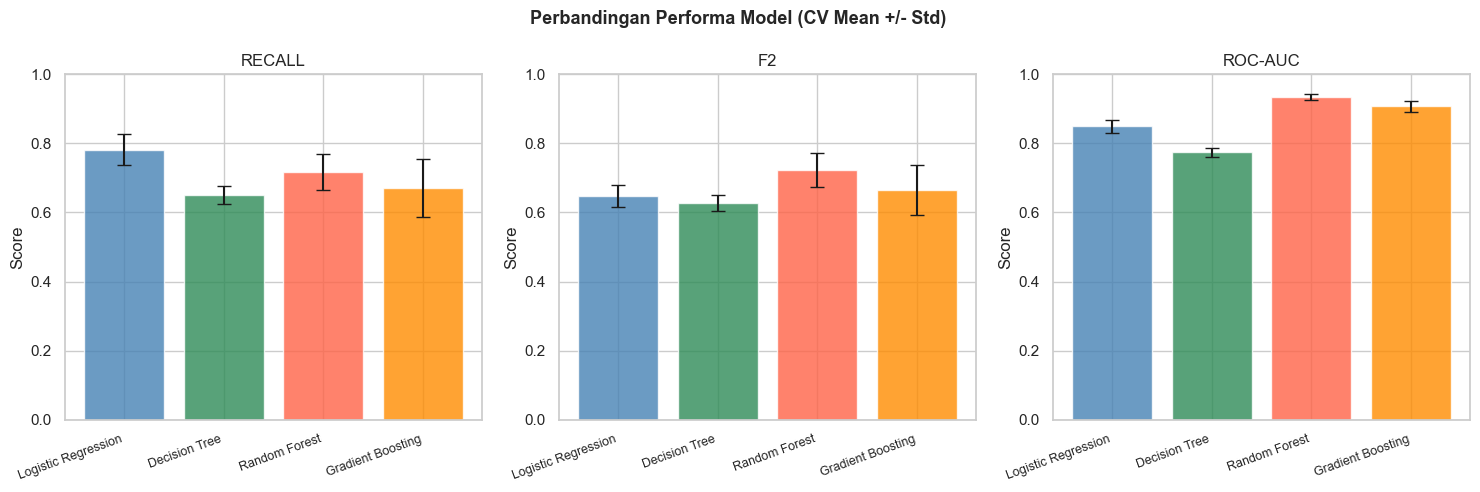

In [32]:
metrics_to_plot = ['recall', 'f2', 'roc_auc']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

for i, metric in enumerate(metrics_to_plot):
    model_names = list(benchmark_results.keys())
    means = [benchmark_results[m][metric]['mean'] for m in model_names]
    stds  = [benchmark_results[m][metric]['std']  for m in model_names]
    axes[i].bar(model_names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    axes[i].set_title(metric.upper().replace('_', '-'))
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel('Score')
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=20, ha='right', fontsize=9)

plt.suptitle('Perbandingan Performa Model (CV Mean +/- Std)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### **6.4 Tune Model**

> 🎯 *Tujuan:* Hyperparameter tuning pada kandidat terbaik.

In [33]:
param_grid_rf = {
    'model__n_estimators'     : [100, 200],
    'model__max_depth'        : [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight'     : ['balanced', None]
}

rf_pipe = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='recall',
                       n_jobs=-1, verbose=0, refit=True)

print("Menjalankan GridSearchCV untuk Random Forest...")
grid_rf.fit(X_train, y_train)
print(f"Best params : {grid_rf.best_params_}")
print(f"Best Recall : {grid_rf.best_score_:.4f}")

Menjalankan GridSearchCV untuk Random Forest...
Best params : {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Recall : 0.7213


In [34]:
param_grid_gb = {
    'model__n_estimators' : [100, 200],
    'model__max_depth'    : [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample'    : [0.8, 1.0]
}

gb_pipe = make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))
grid_gb = GridSearchCV(gb_pipe, param_grid_gb, cv=cv, scoring='recall',
                       n_jobs=-1, verbose=0, refit=True)

print("Menjalankan GridSearchCV untuk Gradient Boosting...")
grid_gb.fit(X_train, y_train)
print(f"Best params : {grid_gb.best_params_}")
print(f"Best Recall : {grid_gb.best_score_:.4f}")

Menjalankan GridSearchCV untuk Gradient Boosting...
Best params : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best Recall : 0.7119


In [35]:
if grid_rf.best_score_ >= grid_gb.best_score_:
    best_model      = grid_rf.best_estimator_
    best_model_name = "Random Forest (Tuned)"
else:
    best_model      = grid_gb.best_estimator_
    best_model_name = "Gradient Boosting (Tuned)"

print(f"Model Final Terpilih : {best_model_name}")
print(f"Best CV Recall       : {max(grid_rf.best_score_, grid_gb.best_score_):.4f}")

Model Final Terpilih : Random Forest (Tuned)
Best CV Recall       : 0.7213


### **6.5 Analyze Model**

> 🎯 *Tujuan:* Evaluasi mendalam pada data testing.

In [36]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Evaluasi Final — {best_model_name}")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F2-Score      : {f2_score_fn(y_test, y_pred):.4f}")

Evaluasi Final — Random Forest (Tuned)
              precision    recall  f1-score   support

 Tidak Churn       0.96      0.94      0.95       547
       Churn       0.72      0.82      0.77       107

    accuracy                           0.92       654
   macro avg       0.84      0.88      0.86       654
weighted avg       0.92      0.92      0.92       654

ROC-AUC Score : 0.9597
F2-Score      : 0.7985


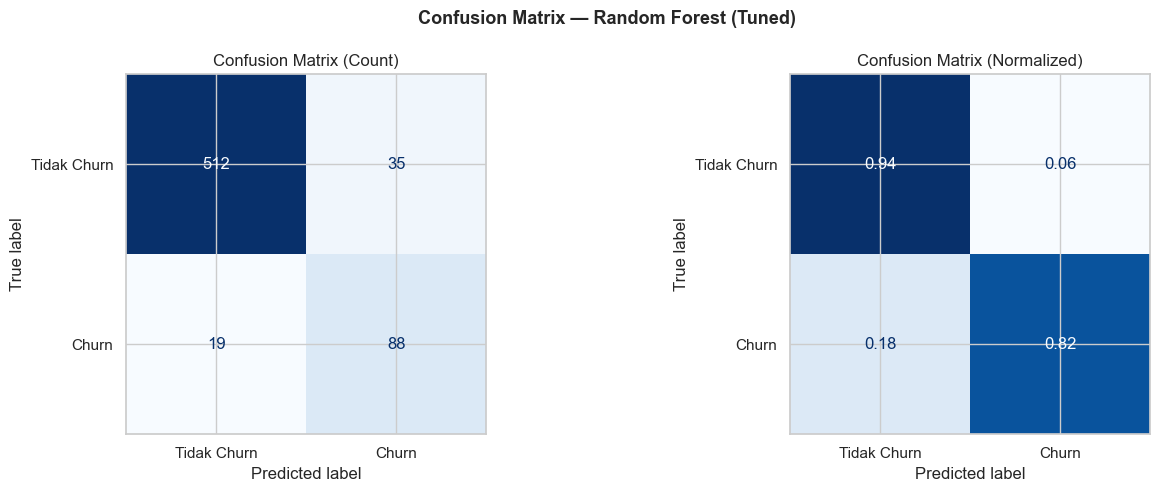

TP (Churn terdeteksi benar)      : 88
FN (Churn TIDAK terdeteksi)      : 19  <- berbahaya bagi bisnis!
FP (Tidak churn, diprediksi churn): 35  <- biaya sia-sia
TN (Tidak churn terdeteksi benar): 512


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Tidak Churn', 'Churn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Count)')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Tidak Churn', 'Churn']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.suptitle(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP (Churn terdeteksi benar)      : {tp}")
print(f"FN (Churn TIDAK terdeteksi)      : {fn}  <- berbahaya bagi bisnis!")
print(f"FP (Tidak churn, diprediksi churn): {fp}  <- biaya sia-sia")
print(f"TN (Tidak churn terdeteksi benar): {tn}")

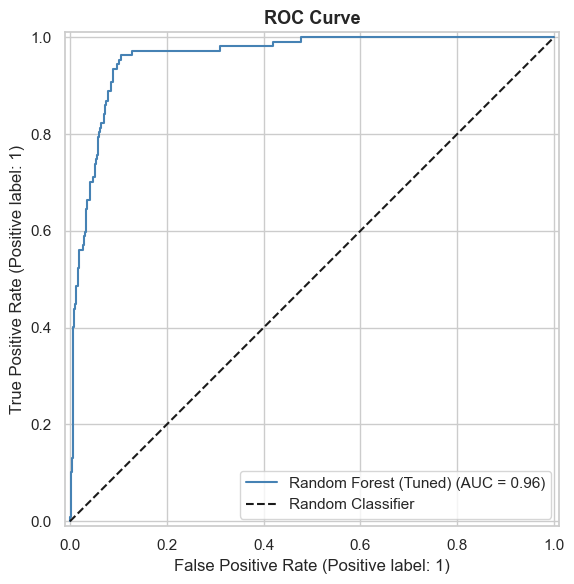

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax,
                                  name=best_model_name, color='steelblue')
ax.plot([0,1],[0,1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

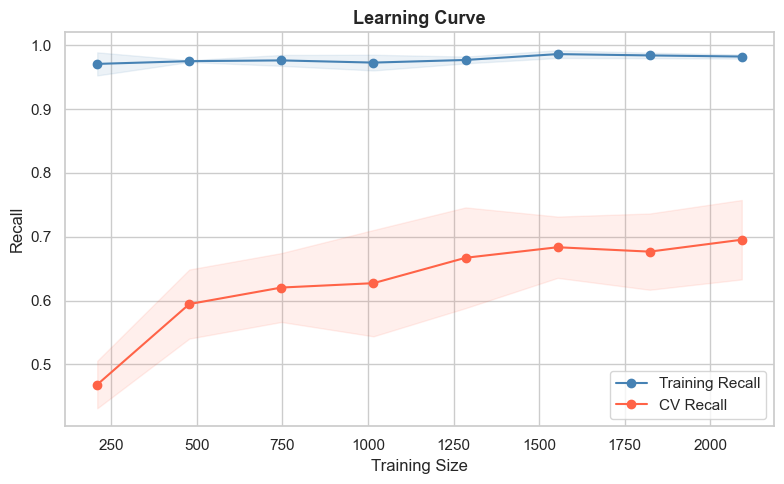

In [39]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=cv, scoring='recall', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8)
)

t_mean, t_std = train_scores.mean(1), train_scores.std(1)
v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, t_mean, 'o-', color='steelblue', label='Training Recall')
plt.plot(train_sizes, v_mean, 'o-', color='tomato',    label='CV Recall')
plt.fill_between(train_sizes, t_mean-t_std, t_mean+t_std, alpha=0.1, color='steelblue')
plt.fill_between(train_sizes, v_mean-v_std, v_mean+v_std, alpha=0.1, color='tomato')
plt.xlabel('Training Size')
plt.ylabel('Recall')
plt.title('Learning Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### **6.6 Model Calibration — Threshold Analysis**

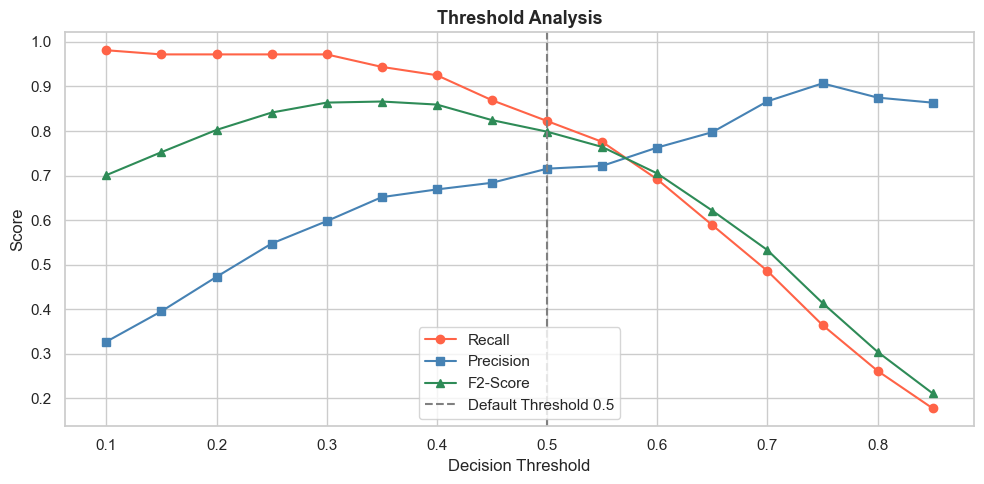

Rekomendasi threshold (F2 tertinggi): 0.35
  Recall    : 0.9439
  Precision : 0.6516
  F2-Score  : 0.8662


In [40]:
thresholds      = np.arange(0.1, 0.9, 0.05)
recall_list     = []
precision_list  = []
f2_list         = []

for t in thresholds:
    y_t = (y_proba >= t).astype(int)
    recall_list.append(recall_score(y_test, y_t))
    precision_list.append(precision_score(y_test, y_t, zero_division=0))
    f2_list.append(f2_score_fn(y_test, y_t))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recall_list,    'o-', label='Recall',    color='tomato')
plt.plot(thresholds, precision_list, 's-', label='Precision', color='steelblue')
plt.plot(thresholds, f2_list,        '^-', label='F2-Score',  color='seagreen')
plt.axvline(0.5, color='gray', linestyle='--', label='Default Threshold 0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

best_idx    = int(np.argmax(f2_list))
best_thresh = thresholds[best_idx]
print(f"Rekomendasi threshold (F2 tertinggi): {best_thresh:.2f}")
print(f"  Recall    : {recall_list[best_idx]:.4f}")
print(f"  Precision : {precision_list[best_idx]:.4f}")
print(f"  F2-Score  : {f2_list[best_idx]:.4f}")

### **6.7 Model Explanation — Feature Importance**

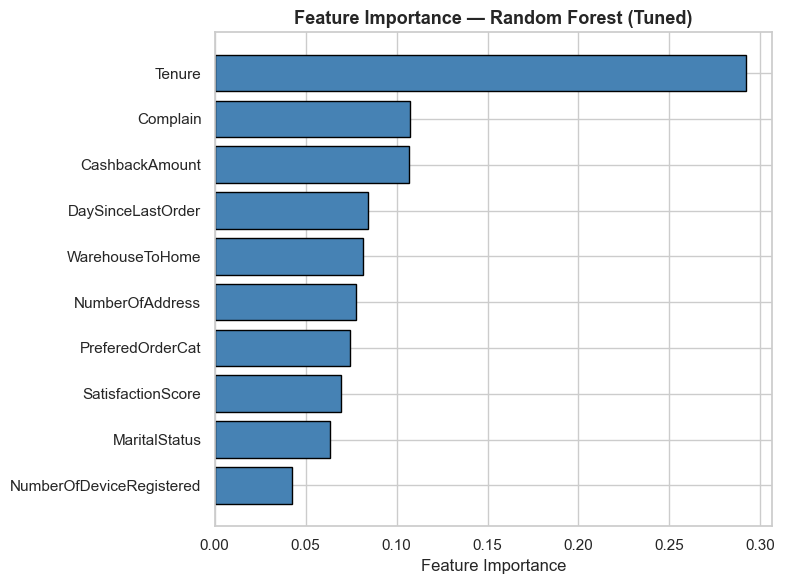

Top 5 Fitur Terpenting:
          Feature  Importance
           Tenure    0.291875
         Complain    0.107280
   CashbackAmount    0.107064
DaySinceLastOrder    0.084064
  WarehouseToHome    0.081429


In [41]:
try:
    fi = best_model.named_steps['model'].feature_importances_
    feat_names = num_missing + num_no_missing + cat_features
    fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': fi}).sort_values(
        'Importance', ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='black')
    plt.xlabel('Feature Importance')
    plt.title(f'Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Top 5 Fitur Terpenting:")
    print(fi_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))
except Exception as e:
    print(f"Feature importance tidak tersedia: {e}")

## **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook.

### **7.1 Export Model**

In [42]:
MODEL_PATH = 'churn_prediction_model.pkl'
joblib.dump(best_model, MODEL_PATH)
print(f"Model berhasil disimpan ke: {MODEL_PATH}")
print(f"Model yang disimpan        : {best_model_name}")

Model berhasil disimpan ke: churn_prediction_model.pkl
Model yang disimpan        : Random Forest (Tuned)


### **7.2 Deployment Checklist**

In [43]:
import sklearn, imblearn
print("=" * 50)
print("DEPLOYMENT CHECKLIST")
print("=" * 50)
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")
print()
print("Format input model (10 kolom, sesuai urutan FEATURES):")
for i, f in enumerate(FEATURES):
    print(f"  [{i}] {f}")
print()
print("Cara memuat ulang model:")
print("  model = joblib.load('churn_prediction_model.pkl')")
print("  preds = model.predict(X_new)")
print("  proba = model.predict_proba(X_new)[:, 1]")

DEPLOYMENT CHECKLIST
pandas  : 2.3.3
numpy   : 2.3.5
sklearn : 1.7.2
imbalanced-learn: 0.14.0

Format input model (10 kolom, sesuai urutan FEATURES):
  [0] Tenure
  [1] WarehouseToHome
  [2] NumberOfDeviceRegistered
  [3] PreferedOrderCat
  [4] SatisfactionScore
  [5] MaritalStatus
  [6] NumberOfAddress
  [7] Complain
  [8] DaySinceLastOrder
  [9] CashbackAmount

Cara memuat ulang model:
  model = joblib.load('churn_prediction_model.pkl')
  preds = model.predict(X_new)
  proba = model.predict_proba(X_new)[:, 1]


## **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model, batasannya, dan dampak bisnis.

### **8.1 How to Implement the Model?**

In [44]:
# Demonstrasi: prediksi pada 5 data baru
loaded_model  = joblib.load('churn_prediction_model.pkl')
X_demo        = X_test.head(5).copy()
y_demo        = y_test.head(5).copy()

y_pred_demo   = loaded_model.predict(X_demo)
y_proba_demo  = loaded_model.predict_proba(X_demo)[:, 1]

demo_df = X_demo.copy()
demo_df['Actual_Churn']      = y_demo.values
demo_df['Predicted_Churn']   = y_pred_demo
demo_df['Churn_Probability'] = y_proba_demo.round(3)

print("Contoh Prediksi pada Data Baru:")
demo_df[['Tenure', 'SatisfactionScore', 'Complain',
         'Actual_Churn', 'Predicted_Churn', 'Churn_Probability']]

Contoh Prediksi pada Data Baru:


,Tenure,SatisfactionScore,Complain,Actual_Churn,Predicted_Churn,Churn_Probability
989,18.0,1,1,0,0,0.106
3071,18.0,5,0,0,0,0.039
607,10.0,3,0,0,0,0.059
226,18.0,4,0,0,0,0.042
1981,1.0,3,1,1,1,0.639


### **8.2 Limitations of the Model**

In [45]:
print("BATASAN MODEL:")
print()
print("1. DATA BOUNDARY:")
print("   - Model dilatih dari data e-commerce spesifik (~3.270 baris setelah deduplikasi).")
print("   - Perlu divalidasi ulang bila digunakan pada platform/segmen berbeda.")
print()
print("2. MODEL BOUNDARY — kurang dapat dipercaya untuk pelanggan dengan:")
print("   - Tenure di luar rentang 0-61 bulan")
print("   - WarehouseToHome > 100 km (nilai sangat jarang di training data)")
print("   - Kategori produk baru yang belum ada di training data")
print()
print("3. TEMPORAL BOUNDARY:")
print("   - Perilaku pelanggan berubah seiring waktu.")
print("   - Disarankan retrain setiap 6 bulan atau saat performa turun.")
print()
print("4. FALSE NEGATIVE RISK:")
print("   - Tidak sempurna — masih ada churn yang lolos deteksi.")
print("   - Perlu dikombinasikan dengan strategi retention proaktif lainnya.")

BATASAN MODEL:

1. DATA BOUNDARY:
   - Model dilatih dari data e-commerce spesifik (~3.270 baris setelah deduplikasi).
   - Perlu divalidasi ulang bila digunakan pada platform/segmen berbeda.

2. MODEL BOUNDARY — kurang dapat dipercaya untuk pelanggan dengan:
   - Tenure di luar rentang 0-61 bulan
   - WarehouseToHome > 100 km (nilai sangat jarang di training data)
   - Kategori produk baru yang belum ada di training data

3. TEMPORAL BOUNDARY:
   - Perilaku pelanggan berubah seiring waktu.
   - Disarankan retrain setiap 6 bulan atau saat performa turun.

4. FALSE NEGATIVE RISK:
   - Tidak sempurna — masih ada churn yang lolos deteksi.
   - Perlu dikombinasikan dengan strategi retention proaktif lainnya.


### **8.3 Business Calculation (Simulation)**

In [46]:
# Asumsi bisnis
AVG_CUSTOMER_VALUE  = 500_000   # nilai pelanggan per tahun (Rp)
RETENTION_COST      = 50_000    # biaya intervensi per pelanggan (Rp)
CHURN_RECOVERY_RATE = 0.30      # 30% yang diintervensi berhasil dipertahankan

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Tanpa model: semua pelanggan churn hilang
loss_without = (tp + fn) * AVG_CUSTOMER_VALUE

# Dengan model
recovered    = tp * CHURN_RECOVERY_RATE * AVG_CUSTOMER_VALUE
cost_tp      = tp * RETENTION_COST
cost_fp      = fp * RETENTION_COST
loss_fn      = fn * AVG_CUSTOMER_VALUE
net_benefit  = recovered - cost_tp - cost_fp

print("=" * 55)
print("SIMULASI DAMPAK BISNIS (Data Testing)")
print("=" * 55)
print(f"Total pelanggan testing          : {len(y_test)}")
print(f"Pelanggan yang sebenarnya churn  : {tp + fn}")
print()
print("TANPA MODEL:")
print(f"  Kerugian potensial             : Rp {loss_without:>15,.0f}")
print()
print("DENGAN MODEL:")
print(f"  TP terdeteksi                  : {tp} pelanggan")
print(f"  FN tidak terdeteksi            : {fn} pelanggan")
print(f"  FP intervensi tidak perlu      : {fp} pelanggan")
print()
print(f"  Pendapatan pulih (TP x 30%)    : Rp {recovered:>15,.0f}")
print(f"  Biaya intervensi TP            : Rp {cost_tp:>15,.0f}")
print(f"  Biaya tidak perlu FP           : Rp {cost_fp:>15,.0f}")
print(f"  Kerugian FN (lolos deteksi)    : Rp {loss_fn:>15,.0f}")
print()
print(f"  NET BENEFIT vs TANPA MODEL     : Rp {net_benefit:>15,.0f}")
print("=" * 55)

SIMULASI DAMPAK BISNIS (Data Testing)
Total pelanggan testing          : 654
Pelanggan yang sebenarnya churn  : 107

TANPA MODEL:
  Kerugian potensial             : Rp      53,500,000

DENGAN MODEL:
  TP terdeteksi                  : 88 pelanggan
  FN tidak terdeteksi            : 19 pelanggan
  FP intervensi tidak perlu      : 35 pelanggan

  Pendapatan pulih (TP x 30%)    : Rp      13,200,000
  Biaya intervensi TP            : Rp       4,400,000
  Biaya tidak perlu FP           : Rp       1,750,000
  Kerugian FN (lolos deteksi)    : Rp       9,500,000

  NET BENEFIT vs TANPA MODEL     : Rp       7,050,000


## **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum proyek dan menerjemahkan hasil teknis ke bahasa bisnis.

### **9.1 Conclusion**

In [47]:
print("KESIMPULAN MODEL:")
print()
print(f"  Final Model : {best_model_name}")
print(f"  Recall      : {recall_score(y_test, y_pred):.4f}  -> {recall_score(y_test, y_pred)*100:.1f}% pelanggan churn terdeteksi")
print(f"  Precision   : {precision_score(y_test, y_pred):.4f}")
print(f"  F2-Score    : {f2_score_fn(y_test, y_pred):.4f}")
print(f"  ROC-AUC     : {roc_auc_score(y_test, y_proba):.4f}")
print()
print("KESIMPULAN BISNIS:")
print()
print("1. Model berhasil mengidentifikasi mayoritas pelanggan yang akan churn,")
print("   memungkinkan tim retention melakukan intervensi proaktif.")
print()
print("2. Faktor utama pendorong churn:")
print("   - Tenure rendah        : pelanggan baru lebih rentan churn")
print("   - SatisfactionScore    : skor kepuasan rendah berkorelasi kuat dengan churn")
print("   - Complain             : pelanggan yang pernah komplain berisiko lebih tinggi")
print("   - DaySinceLastOrder    : semakin lama tidak order -> semakin berisiko churn")
print()
print("3. Dengan model ini, perusahaan dapat menekan kerugian akibat churn secara signifikan.")

KESIMPULAN MODEL:

  Final Model : Random Forest (Tuned)
  Recall      : 0.8224  -> 82.2% pelanggan churn terdeteksi
  Precision   : 0.7154
  F2-Score    : 0.7985
  ROC-AUC     : 0.9597

KESIMPULAN BISNIS:

1. Model berhasil mengidentifikasi mayoritas pelanggan yang akan churn,
   memungkinkan tim retention melakukan intervensi proaktif.

2. Faktor utama pendorong churn:
   - Tenure rendah        : pelanggan baru lebih rentan churn
   - SatisfactionScore    : skor kepuasan rendah berkorelasi kuat dengan churn
   - Complain             : pelanggan yang pernah komplain berisiko lebih tinggi
   - DaySinceLastOrder    : semakin lama tidak order -> semakin berisiko churn

3. Dengan model ini, perusahaan dapat menekan kerugian akibat churn secara signifikan.


### **9.2 Recommendation**

In [48]:
print("REKOMENDASI MODEL:")
print()
print("  BAIK digunakan untuk:")
print("    - Pelanggan aktif dengan profil serupa data training")
print("    - Evaluasi batch periodik (mingguan/bulanan)")
print("    - Prioritisasi daftar intervensi berdasarkan probabilitas churn")
print()
print("  KURANG OPTIMAL untuk:")
print("    - Pelanggan baru (Tenure < 1 bulan) — data historis terbatas")
print("    - Segmen dengan pola sangat berbeda dari training data")
print()
print("REKOMENDASI BISNIS:")
print()
print("  1. Program Retensi Berbasis Segmentasi:")
print("     - HIGH RISK   (prob > 0.7)  : voucher besar + personal outreach")
print("     - MEDIUM RISK (0.4 - 0.7)   : notifikasi promo & loyalty point")
print("     - LOW RISK    (< 0.4)        : maintenance engagement rutin")
print()
print("  2. Fokus Intervensi pada Trigger Utama Churn:")
print("     - Follow-up komplain dalam 24 jam")
print("     - Re-engagement campaign untuk pelanggan 7+ hari tidak order")
print("     - Onboarding intensif untuk Tenure < 3 bulan")
print()
print("  3. Improvement Model ke Depan:")
print("     - Tambahkan fitur: frekuensi pembelian, total spending, channel transaksi")
print("     - Coba XGBoost / LightGBM untuk performa lebih tinggi")
print("     - Monitoring data drift untuk deteksi degradasi model")
print("     - Retrain setiap 6 bulan dengan data terbaru")

REKOMENDASI MODEL:

  BAIK digunakan untuk:
    - Pelanggan aktif dengan profil serupa data training
    - Evaluasi batch periodik (mingguan/bulanan)
    - Prioritisasi daftar intervensi berdasarkan probabilitas churn

  KURANG OPTIMAL untuk:
    - Pelanggan baru (Tenure < 1 bulan) — data historis terbatas
    - Segmen dengan pola sangat berbeda dari training data

REKOMENDASI BISNIS:

  1. Program Retensi Berbasis Segmentasi:
     - HIGH RISK   (prob > 0.7)  : voucher besar + personal outreach
     - MEDIUM RISK (0.4 - 0.7)   : notifikasi promo & loyalty point
     - LOW RISK    (< 0.4)        : maintenance engagement rutin

  2. Fokus Intervensi pada Trigger Utama Churn:
     - Follow-up komplain dalam 24 jam
     - Re-engagement campaign untuk pelanggan 7+ hari tidak order
     - Onboarding intensif untuk Tenure < 3 bulan

  3. Improvement Model ke Depan:
     - Tambahkan fitur: frekuensi pembelian, total spending, channel transaksi
     - Coba XGBoost / LightGBM untuk performa lebi